# TimesFM — Model Experiment
**Dataset:** Monthly Labor Market (`monthly_labor_market.csv`)  
**Target:** `EMPLOY`  
**Horizon:** 12 months  
**Split:** 80 % train / last 12 months test  
**Metrics:** MAE, MSE  
**Model:** TimesFM pretrained — `google/timesfm-1.0-200m-pytorch`

In [11]:
# tsfm-public uses transformers.utils.download_url which was removed in transformers>=4.47.
# Pin to the last compatible version before running this notebook.
# Uncomment and run once per environment:
# !pip install tsfm-public "transformers<4.47" torch scikit-learn pandas matplotlib ipykernel


In [12]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


In [14]:
TARGET = "EMPLOY"

In [15]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:split + 12]

y_true = test_df[TARGET].values

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (596, 9)
Test shape:  (12, 9)


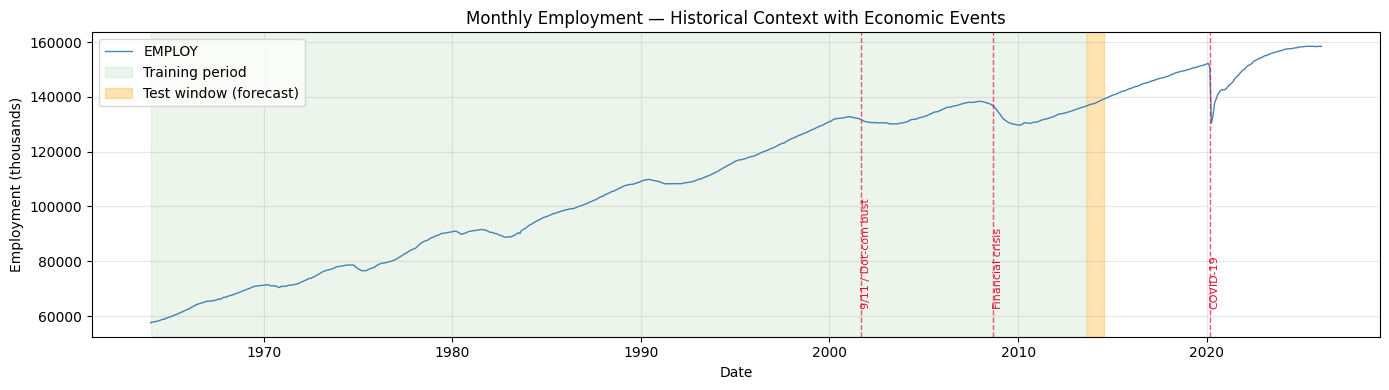

In [16]:
EVENTS = {
    "2001-09-01": "9/11 / Dot-com bust",
    "2008-09-01": "Financial crisis",
    "2020-03-01": "COVID-19",
}

y_max = df[TARGET].max()
y_min = df[TARGET].min()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ds"], df[TARGET], color="steelblue", linewidth=1, label=TARGET)

ax.axvspan(train_df["ds"].iloc[0], train_df["ds"].iloc[-1],
           alpha=0.08, color="green", label="Training period")
ax.axvspan(test_df["ds"].iloc[0], test_df["ds"].iloc[-1],
           alpha=0.3, color="orange", label="Test window (forecast)")

for date, label in EVENTS.items():
    ts = pd.Timestamp(date)
    ax.axvline(ts, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(ts, y_min + (y_max - y_min) * 0.05, label,
            rotation=90, fontsize=8, color="crimson", va="bottom")

ax.set_title("Monthly Employment — Historical Context with Economic Events")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
import timesfm

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="cpu",   # change to "gpu" if CUDA available
        per_core_batch_size=32,
        horizon_len=12,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)

print("TimesFM loaded.")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

TimesFM loaded.


In [18]:
context = [train_df[TARGET].values.astype(np.float32)]

point_forecast, _ = tfm.forecast(
    inputs=context,
    freq=[0],
)

timesfm_pred = point_forecast[0][:12]

print("Shape:     ", timesfm_pred.shape)
print("Prediction:", timesfm_pred)

Shape:      (12,)
Prediction: [136287.66 136369.25 136937.88 137119.84 137485.6  137739.48 138136.56
 138135.72 138516.33 138932.48 139143.95 139220.19]


In [19]:
timesfm_mae = mean_absolute_error(y_true, timesfm_pred)
timesfm_mse = mean_squared_error(y_true, timesfm_pred)
print(f"TimesFM  MAE: {timesfm_mae:.2f}")
print(f"TimesFM  MSE: {timesfm_mse:.2f}")

TimesFM  MAE: 205.06
TimesFM  MSE: 84442.56


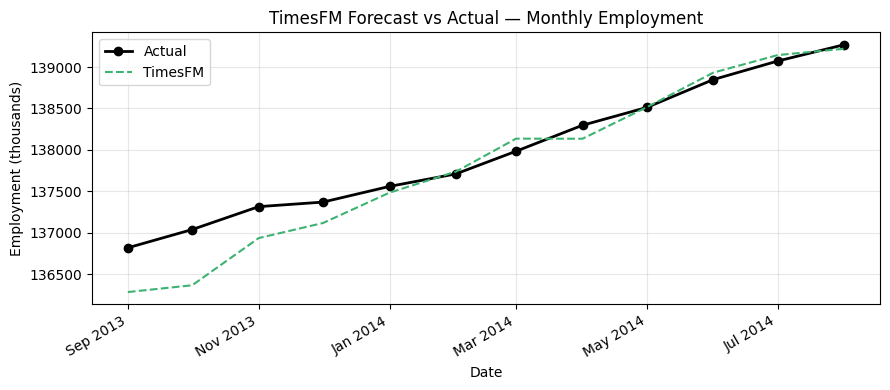


Model               MAE            MSE
--------------------------------------
TimesFM          205.06       84442.56


In [20]:
forecast_dates = test_df["ds"].values

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(forecast_dates, y_true,
        color="black", marker="o", label="Actual", linewidth=2)
ax.plot(forecast_dates, timesfm_pred,
        linestyle="--", color="mediumseagreen", label="TimesFM", linewidth=1.5)
ax.set_title("TimesFM Forecast vs Actual — Monthly Employment")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\n{'Model':<12} {'MAE':>10} {'MSE':>14}")
print("-" * 38)
print(f"{'TimesFM':<12} {timesfm_mae:>10.2f} {timesfm_mse:>14.2f}")